In [2]:
# Setup environment
import sys
import os.path
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
  Using cached coffea-0.7.31-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached ipykernel-6.31.0-py3-none-any.whl.metadata (4.5 kB)
INFO: pip is looking at multiple versions of coffea to determine which version is compatible with other requirements. This could take a while.
  Using cached coffea-0.7.30-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.29-py2.py3-non

In [3]:
# Import basic libraries
import copy
import os

# In case any of these imports fails, please restart the jupyter kernel and try again - it is likely the environment just needs to be updated
import requests
import uproot   # handle ROOT files
import awkward as ak    # nested, variable sized data arrays
import numpy as np
import vector   # Lorentz vectors
vector.register_awkward()
import matplotlib.pyplot as plt # plotting
import matplotlib
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})
from tqdm import tqdm   # progress bars
import atlasopenmagic as atom   # ATLAS Open Data
from concurrent.futures import ProcessPoolExecutor, as_completed # Parallel execution for processing large datasets
import time

In [4]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )

In [12]:
atom.set_release("2024r-hi")
sample_defs = {
    "Data": {'dids': ["data"], 'color': 'red'}
}
data_samples = atom.build_dataset(sample_defs,skim="noskim",protocol="https",cache=True)
samples = {**data_samples}

Fetching and caching all metadata for release: 2024r-hi...
Successfully cached 2 datasets.
Active release: 2024r-hi. (Datasets path: REMOTE)


In [50]:
bins, h_range = 100, (0,5e6)
bw = 20e3 # MeV
fine_bins = int(5e6 / bw) # Bins for 20 GeV bin width
print(fine_bins) 
_ , bin_edges = np.histogram([-1],fine_bins,h_range)

250


In [40]:
urls = atom.get_urls("data",protocol="https",cache=True)
# Switch to atom build dataset
fraction = 0.01
variables = [f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")]
def process_dataset(url:str,loop:int):
    if loop > 99: raise IndexError("Can't iterate past 100 pct of the dataset!")
    with uproot.open(f"{url}:CollectionTree") as tree:

        total_hist,_ = np.histogram([-1],bins=fine_bins,range=h_range)
        for data in tree.iterate(variables, library="ak", entry_start=int(tree.num_entries*loop*fraction), entry_stop=int(tree.num_entries*(loop+1)*fraction)):
            total_et = data[variables[0]] + data[variables[1]]
            this_hist,_ = np.histogram(total_et,bins=fine_bins,range=h_range)
            total_hist = total_hist + this_hist
            
    return total_hist

def full_process_data(url:str):
    with uproot.open(f"{url}:CollectionTree") as tree:
        fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )})
        fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
        this_hist,_ = np.histogram(fcal["TotalEt"],bins=fine_bins,range=h_range)

    return this_hist


            
blocks = " ▁▂▃▄▅▆▇█"

def to_sparkline(hist):
    if max(hist) == 0:
        return blocks[0] * len(hist)
    normalised = hist / max(hist)
    return f'{"".join(blocks[int(v * (len(blocks) - 1))] for v in normalised)} Events: {int(np.sum(hist))}'

total_hist = full_process_data(urls[0])
print(to_sparkline(total_hist))

     ▆▇█▅▆▅▄▅▃▄▄▃▄▂▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▂▂▂▂▁▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁ ▁▁▁▁▁▁▁▁ ▁▁▁▁ ▁▁▁▁▁▁▁▁▁▁ ▁ ▁▁ ▁ ▁▁  ▁ ▁         ▁       ▁       ▁             ▁              ▁                                                                                    Events: 7767


In [31]:
def parallel_processing(url:str):
    with ProcessPoolExecutor(max_workers=4) as executor:
        futures = {
            executor.submit(process_dataset, url, i): i for i in range(100)
        }

        results = []
        for future in as_completed(futures):
            try: results.append(future.result())
            except Exception as e:
                print(f"Error in {futures[future]}! Got {e}")

        result_hist = np.sum(results,axis=0)

        return result_hist      

In [32]:
print(samples["Data"]["list"][:2])

['https://opendata.cern.ch/eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691901._000001.pool.root.1', 'https://opendata.cern.ch/eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691901._000002.pool.root.1']


In [73]:
start_all = time.time()
hists_all = {}
# Get bin edges and empty histogram
total_eT_hist, bin_edges = np.histogram([-1],bins=fine_bins,range=h_range)
print("Processing datasets...")
print(len(samples["Data"]["list"]))
pbar = tqdm(samples["Data"]["list"][:30],desc=to_sparkline(np.array([total_eT_hist[int((len(total_eT_hist)-1)/50)*i] for i in range(50)])))
# for url in pbar:
#     frames = []
#     H = parallel_processing(url)
#     frames.append(H)
#     total_eT_hist = total_eT_hist + np.sum(frames,axis=0)
#     pbar.set_description(to_sparkline(np.array([total_eT_hist[int((len(total_eT_hist)-1)/50)*i] for i in range(50)])))
for url in pbar:
    H = full_process_data(url)
    total_eT_hist = total_eT_hist + H
    pbar.set_description(to_sparkline(np.array([total_eT_hist[int((len(total_eT_hist)-1)/50)*i] for i in range(50)])))

end_all = time.time()
print(f"Total time: {round((end_all - start_all) / 60, 1)} mins")

Processing datasets...
1913


█                                                  Events: 725705: 100%|██████████| 30/30 [06:38<00:00, 13.29s/it]

Total time: 6.6 mins


In [74]:
print(total_eT_hist)

[3.99e+05, 1.02e+05, 6.54e+04, 4.98e+04, 4.08e+04, 3.71e+04, ..., 0, 2, 1, 0, 1]


█                                                  Events: 725705
[3.99e+05, 1.02e+05, 6.54e+04, 4.98e+04, 4.08e+04, 3.71e+04, ..., 0, 2, 1, 0, 1]
[5.26e-07, 1.05e-06, 2.1e-06, 2.63e-06, 4.21e-06, ..., 0.702, 0.737, 0.79, 1]
[np.int64(33), np.int64(92), np.int64(142), np.int64(247)]


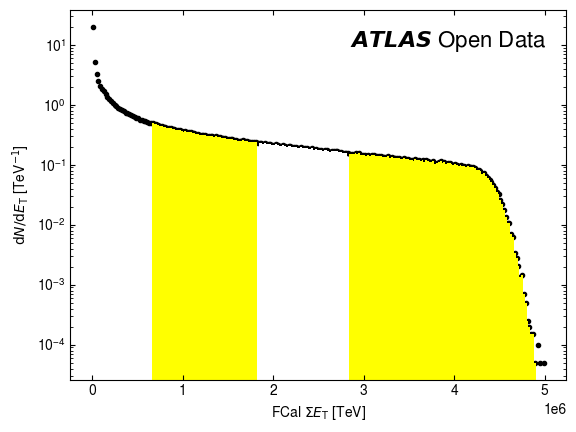

In [ ]:
fig, ax = plt.subplots()
nbins = 50
print(to_sparkline(np.array([total_eT_hist[int((len(total_eT_hist)-1)/50)*i] for i in range(50)])))
diff_hist = total_eT_hist / (bin_edges[1] - bin_edges[0])
# ax.stairs(diff_hist,bin_edges*1e-6,color="blue")
ax.scatter(bin_edges[:-1]+bw*.5,diff_hist,color="black",marker=".")
ax.set_yscale("log")
inner_ticks(ax); atlas_label(ax)
ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [TeV]"); ax.set_ylabel(r"$\mathrm{d}N/\mathrm{d}E_{\mathrm{T}}$ [TeV$^{-1}$]")

norm_cum_int = np.cumsum(np.flip(total_eT_hist[total_eT_hist!=0])) / np.sum(total_eT_hist)
integral = diff_hist * bw; print(integral)
print(norm_cum_int)

centrality_ranges = {
    40: "40 - 100 %",
    20: "20 - 40%",
    10: "10 - 20%",
    0: "0 - 10%"
}
centrality_ix = [np.argmin(np.abs(np.flip(norm_cum_int) - c*.01)) for c in centrality_ranges]
centrality_ix[::-1]
print(centrality_ix)
for i,col in zip(range(len(centrality_ranges)-1),("yellow","white","yellow")):
    ax.stairs(diff_hist[centrality_ix[i]:centrality_ix[i+1]-1],bin_edges[centrality_ix[i]:centrality_ix[i+1]],fill=True,color=col)
# for ix,col in zip(centrality_ix[:-1],("yellow","white","yellow","white")):
#     ax.stairs(diff_hist[:ix-1],bin_edges[:ix],fill=True,color=col)
#     ax.vlines(bin_edges[ix],*ax.get_ylim(),color="red")

In [ ]:
total_transverse_energies = ak.Array([])

for i,url in tqdm(enumerate(urls),desc="Grabbing total transverse energies...",total=len(urls)):
    with uproot.open(f"{url}:CollectionTree") as tree:
        fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )})
        fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
        total_transverse_energies = ak.concatenate([total_transverse_energies,ak.flatten(fcal["TotalEt"],axis=None)])
    if i == 2: break

print(total_transverse_energies)

Grabbing total transverse energies...:   0%|          | 0/1913 [00:00<?, ?it/s]


TypeError: 'ClientResponseError' object is not subscriptable

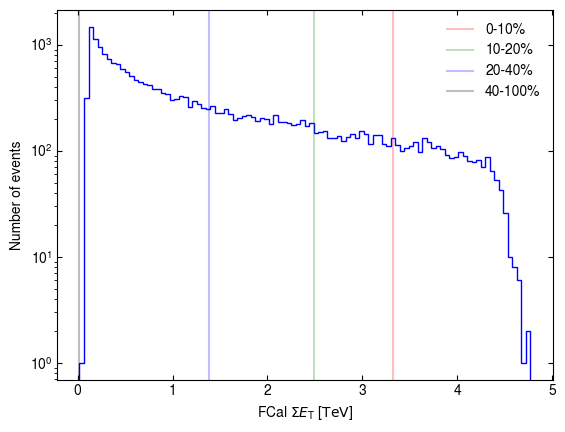

In [ ]:
fig, ax = plt.subplots()
ax.hist(total_transverse_energies*1e-6,bins=100,histtype="step",color="blue")
ax.tick_params(axis="both",direction="in",top=True,right=True)
ax.set_yscale("log")
ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [$\mathrm{TeV}$]")
ax.set_ylabel("Number of events")
centrality_ranges = {
    10: "0 - 10%",
    20: "10 - 20%",
    40: "20 - 40%",
    100:"40 - 100%"
}
centralities = [0,10,20,40,100]
centrality_bins = np.array([np.percentile(total_transverse_energies,100-x) for x in centralities[1:]])
ymax = ax.get_ylim()[1]
# plt.vlines(centrality_bins*1e-6,0,ymax,alpha=.33,color="k")
for i,colour in zip(range(4),("red","green","blue","k")):
    plt.vlines(centrality_bins[i]*1e-6,0,ymax,color=colour,alpha=.25,label=f"{centralities[i]}-{centralities[i+1]}%")

plt.legend(frameon=False)

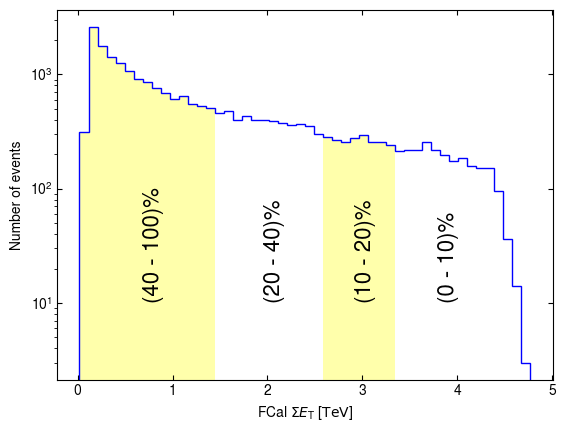

In [ ]:
fig, ax = plt.subplots()
nbins = 50
entries, bin_edges = np.histogram(total_transverse_energies*1e-6, bins=nbins)

centrality_ranges = {
    10: "(0 - 10)%",
    20: "(10 - 20)%",
    40: "(20 - 40)%",
    100:"(40 - 100)%"
}
centralities = [0,10,20,40,100]
centrality_bins = np.array([bin_edges[-1]])
centrality_bins = np.concatenate([centrality_bins,np.array([np.percentile(total_transverse_energies,100-x) for x in centralities[1:]])*1e-6],)

colours = ["white","yellow","white","yellow"]
for i in range(len(centrality_bins)-1):
    mask = (bin_edges[:-1] <= centrality_bins[i]) & (bin_edges[:-1] >= centrality_bins[i+1])
    masked_entries = np.where(mask,entries,0)
    y_txt = 10
    x_txt = np.median(bin_edges[mask]) if i != 0 else 3.8
    ax.stairs(masked_entries,bin_edges,fill=True,color=colours[i],alpha=.33,label="hi")
    ax.text(x_txt,y_txt,centrality_ranges[centralities[i+1]],rotation=90,fontsize=16,ha="left",va="bottom")

ax.tick_params(axis="both",direction="in",top=True,right=True)
ax.set_yscale("log")
ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [$\mathrm{TeV}$]")
ax.set_ylabel("Number of events")
_ = ax.stairs(entries, bin_edges, color="blue")